# Pothole image classification with LIME
Train a pothole classifier and explain five local sample images with LIME.

In [ ]:
%pip install -q kagglehub lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from pathlib import Path
import kagglehub, matplotlib.pyplot as plt, numpy as np, pandas as pd, tensorflow as tf
from PIL import Image
from lime import lime_image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from skimage.segmentation import mark_boundaries

SEED=42; IMG_SIZE=(224,224); BATCH_SIZE=32
CLASS_NAMES=np.array(['normal','potholes'])
np.random.seed(SEED); tf.random.set_seed(SEED)

## Load the dataset
Download the Kaggle dataset and collect the images from the `normal` and `potholes` folders.

In [ ]:
root=Path(kagglehub.dataset_download('atulyakumar98/pothole-detection-dataset'))
extensions={'.jpg','.jpeg','.png','.bmp','.webp'}

def class_folder(name):
    matches=[p for p in root.rglob('*') if p.is_dir() and p.name.lower()==name]
    return min(matches,key=lambda p:len(p.parts))

def files(folder):
    return sorted(str(p) for p in folder.rglob('*') if p.suffix.lower() in extensions)

normal=files(class_folder('normal')); potholes=files(class_folder('potholes'))
paths=np.array(normal+potholes); labels=np.array([0]*len(normal)+[1]*len(potholes))
pd.Series(labels).map(dict(enumerate(CLASS_NAMES))).value_counts()

Using Colab cache for faster access to the 'pothole-detection-dataset' dataset.


,count
normal,352
potholes,329


## Prepare the images

In [ ]:
train_paths,test_paths,train_labels,test_labels=train_test_split(paths,labels,test_size=.2,stratify=labels,random_state=SEED)
train_paths,val_paths,train_labels,val_labels=train_test_split(train_paths,train_labels,test_size=.2,stratify=train_labels,random_state=SEED)

def load_image(path,label):
    x=tf.io.decode_image(tf.io.read_file(path),channels=3,expand_animations=False); x.set_shape([None,None,3])
    return tf.image.resize(x,IMG_SIZE),tf.cast(label,tf.float32)

def dataset(p,y,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((p,y))
    if shuffle: ds=ds.shuffle(len(p),seed=SEED)
    return ds.map(load_image,num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds=dataset(train_paths,train_labels,True); val_ds=dataset(val_paths,val_labels); test_ds=dataset(test_paths,test_labels)
print(len(train_paths),len(val_paths),len(test_paths))

435 109 137


## Train the classifier

In [ ]:
base=tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE+(3,),include_top=False,weights='imagenet'); base.trainable=False
model=tf.keras.Sequential([tf.keras.Input(IMG_SIZE+(3,)),tf.keras.layers.RandomFlip('horizontal'),tf.keras.layers.Rescaling(1/127.5,offset=-1),base,tf.keras.layers.GlobalAveragePooling2D(),tf.keras.layers.Dropout(.2),tf.keras.layers.Dense(1,activation='sigmoid')])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[tf.keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6207 - loss: 0.6709 - val_accuracy: 0.7982 - val_loss: 0.4557
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.9011 - loss: 0.2929 - val_accuracy: 0.9174 - val_loss: 0.2864
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 477ms/step - accuracy: 0.9517 - loss: 0.1839 - val_accuracy: 0.9174 - val_loss: 0.2396
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - accuracy: 0.9724 - loss: 0.1438 - val_accuracy: 0.9266 - val_loss: 0.2152
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 495ms/step - accuracy: 0.9839 - loss: 0.1081 - val_accuracy: 0.9266 - val_loss: 0.2072
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 438ms/step - accuracy: 0.9747 - loss: 0.0993 - val_accuracy: 0.9266 - val_loss: 0.1977
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 735ms/step - accuracy: 0.9839 - loss: 0.0887 - val_accuracy: 0.9266 - val_loss: 0.1946
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 687ms/step - ac

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Evaluate the classifier

              precision    recall  f1-score   support

      normal       0.97      0.97      0.97        71
    potholes       0.97      0.97      0.97        66

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



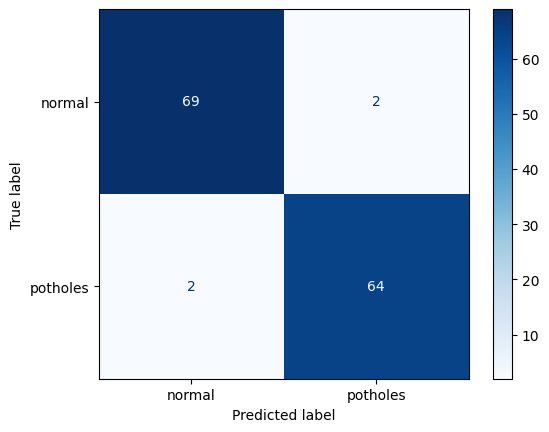

In [7]:
prob=model.predict(test_ds,verbose=0).ravel(); pred=(prob>=.5).astype(int)
print(classification_report(test_labels,pred,target_names=CLASS_NAMES))
ConfusionMatrixDisplay.from_predictions(test_labels,pred,display_labels=CLASS_NAMES,cmap='Blues'); plt.show()

## Explain five local images with LIME
The classifier is trained on the full Kaggle dataset. The five explanations below use only the images stored in `data/pothole_classification/`. LIME highlights the regions that most support each predicted class.

  0%|          | 0/1000 [00:00<?, ?it/s]

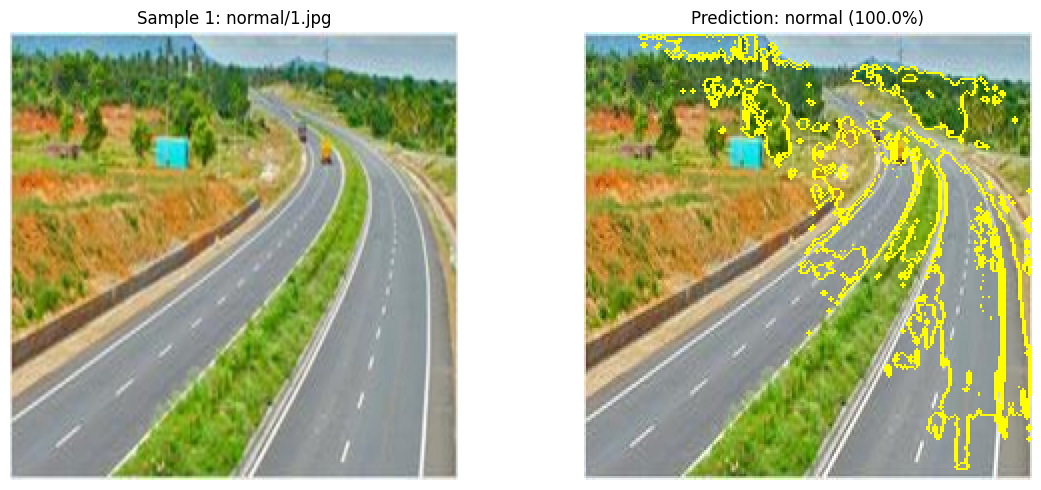

  0%|          | 0/1000 [00:00<?, ?it/s]

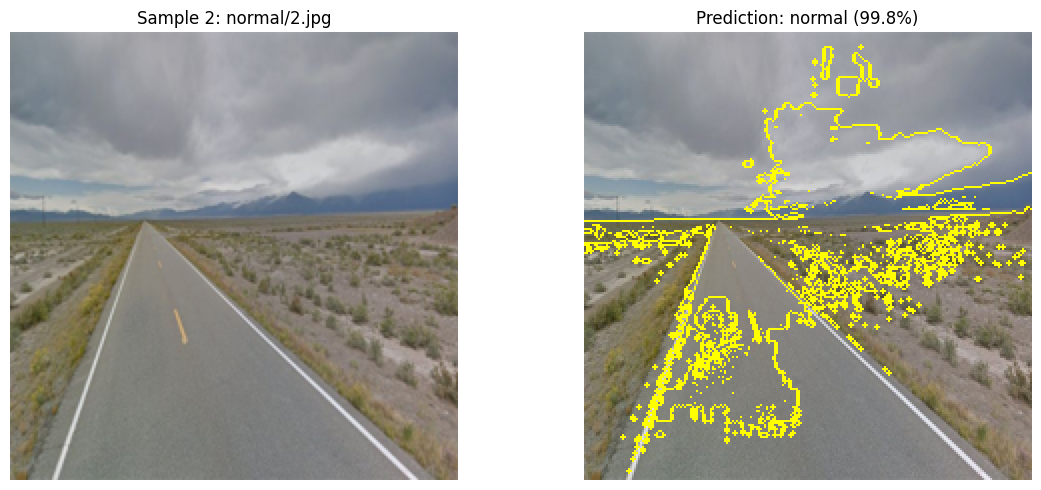

  0%|          | 0/1000 [00:00<?, ?it/s]

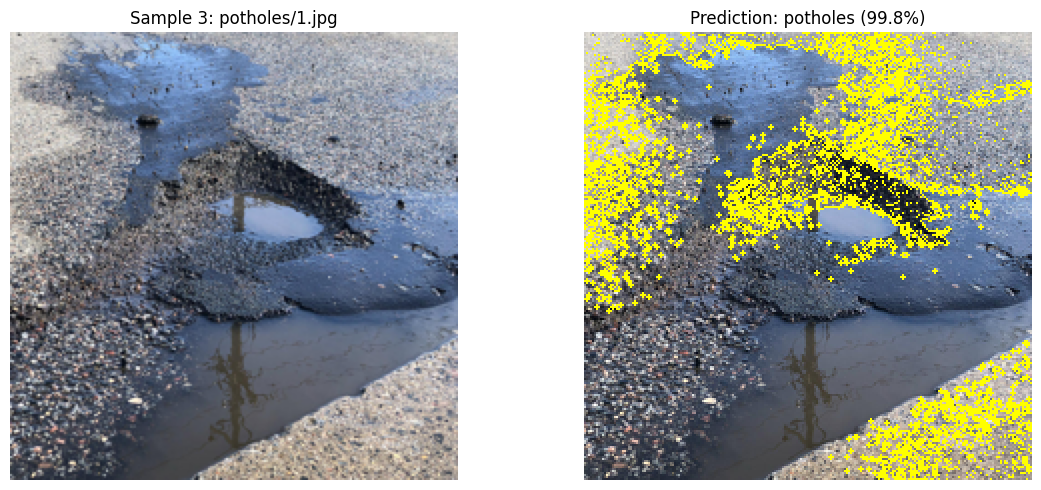

  0%|          | 0/1000 [00:00<?, ?it/s]

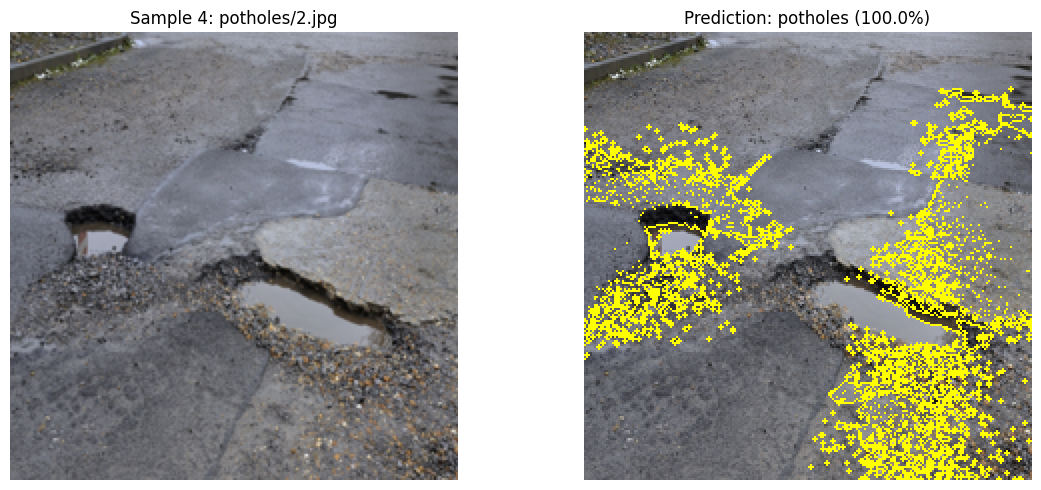

  0%|          | 0/1000 [00:00<?, ?it/s]

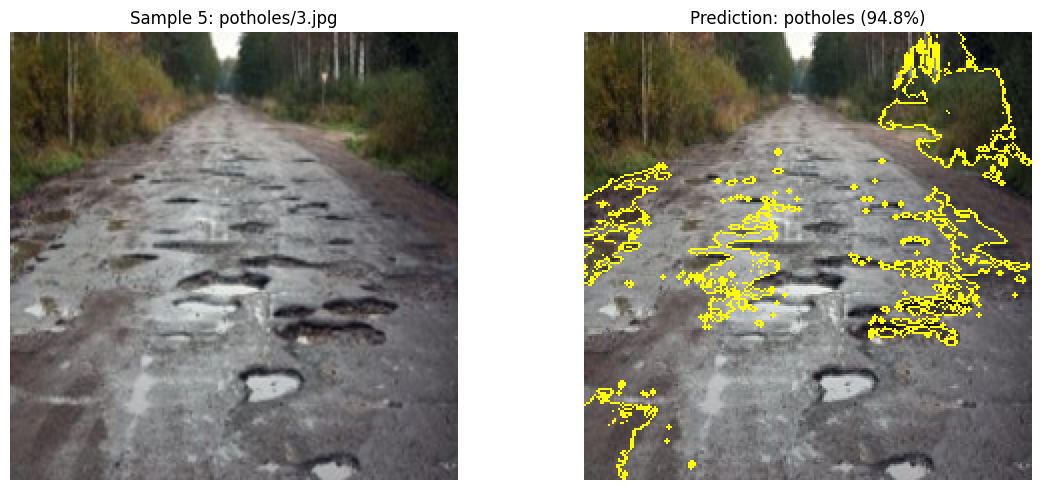

In [9]:
def read_image(path):
    return np.asarray(Image.open(path).convert('RGB').resize(IMG_SIZE),dtype=np.float32)

def predict(images):
    p=model.predict(np.asarray(images,dtype=np.float32),verbose=0).ravel()
    return np.column_stack([1-p,p])

sample_root=Path('data/pothole_classification')
sample_paths=sorted(sample_root.rglob('*.jpg'))
assert len(sample_paths)==5, f'Expected 5 sample images, found {len(sample_paths)}'
explainer=lime_image.LimeImageExplainer(random_state=SEED)

for number,path in enumerate(sample_paths,1):
    image=read_image(path)
    probabilities=predict([image])[0]
    label=int(probabilities.argmax())
    explanation=explainer.explain_instance(
        image.astype(float),predict,labels=(label,),hide_color=0,num_samples=1000
    )
    shown,mask=explanation.get_image_and_mask(
        label,positive_only=True,hide_rest=False,num_features=10
    )
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    axes[0].imshow(image.astype('uint8'))
    axes[0].set_title(f'Sample {number}: {path.parent.name}/{path.name}')
    axes[1].imshow(mark_boundaries(shown/255,mask))
    axes[1].set_title(f'Prediction: {CLASS_NAMES[label]} ({probabilities[label]:.1%})')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

Each explanation compares the original local image with the regions that most support the model's prediction. Green boundaries should ideally overlap meaningful road damage rather than unrelated scenery or image artifacts.